In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [3]:
np.random.seed(33550336)

In [62]:
rng = np.random.default_rng()

In [50]:
def fit(xt, yt, hp):
    mn1 = np.mean(xt, axis = 0)
    standardd = np.std(xt, axis = 0)
    xt = xt - mn1
    xt = xt/standardd
    mn2 = np.mean(yt, axis = 0)
    stadardd = np.std(yt, axis = 0)
    ysc = (yt - mn2) / stadardd
    sp = np.shape(xt)
    ident = np.eye(sp[1])
    sm = xt.T @ xt + hp * ident
    uf = xt.T @ ysc
    dumb = np.linalg.solve(sm, uf)
    return {"beta": dumb, "x_mean": mn1, "x_std": standardd, "y_mean": mn2, "y_std": stadardd}

In [51]:
def predict(model, xn):
    beta = model["beta"]
    xm = model["x_mean"]
    xstd = model["x_std"]
    ym = model["y_mean"]
    ystd = model["y_std"]
    xn = (xn - xm) / xstd
    preds = xn @ beta
    preds = preds * ystd + ym
    return preds

In [52]:
x = np.random.normal(loc = 2, scale = 1.0, size = (100, 3))
noise = np.random.normal(0, 0.1, size = (100 ,))
y = 3 * x[:, 0] - 2 * x[:, 1] + 0.5 * x[:, 2] + noise
mod = fit(x, y, 1e-8)

In [53]:
mod["beta"] * mod["y_std"]

array([ 2.88814602, -1.88937123,  0.56868161])

In [54]:
x_std = (x - x.mean(axis=0)) / x.std(axis=0)
sklearn.linear_model.LinearRegression().fit(x_std, y).coef_

array([ 2.88814602, -1.88937123,  0.56868161])

In [55]:
pred = predict(mod, x)

In [56]:
pred

array([ 4.70527295,  7.19949635,  0.58840546, -1.28267915,  1.49853838,
        8.22627228,  4.6572042 , -2.58862019, -1.43396312,  1.78022872,
        0.67162587, -1.15530887,  7.99582033, -1.54224564,  0.634021  ,
        3.42780994,  4.15843271, -0.7462806 , -2.13921258,  8.12197307,
        6.10463419, -0.8628403 ,  7.45610092,  3.26758485,  4.32560983,
       -0.08097883,  3.95143002,  1.70669975,  4.3093424 ,  1.66306903,
       -0.43089162,  1.21401003,  0.39327769,  5.46913722,  3.47248727,
        0.3240497 ,  8.86890587,  5.86234146,  1.12472641,  1.36787057,
        1.4478199 , -1.05676052,  4.01929659,  5.23736417,  1.19925867,
        1.66939011, -5.11117742, -2.10798558,  5.48080547, -0.86151365,
        6.14128479, -1.24697737,  1.28817773,  7.80679487,  2.05475069,
       -6.6213623 ,  2.30835474,  1.74925597,  2.56211638, -2.1257544 ,
        2.49967153, -2.68059595,  6.49871052,  8.38345127,  2.32485626,
        2.9461958 ,  4.0078881 ,  6.67178263, -1.22190154,  6.49

In [57]:
y

array([ 4.77874069,  7.09083519,  0.59405138, -1.30140178,  1.38655471,
        8.24357126,  4.55548044, -2.49517263, -1.47224684,  1.69505485,
        0.6325581 , -1.07858125,  8.00270111, -1.65673376,  0.69439608,
        3.55527571,  3.99602966, -0.65644412, -2.12432468,  8.09107143,
        6.08118062, -1.0018598 ,  7.42508918,  3.27974391,  4.2648599 ,
        0.07881058,  3.91266686,  1.55767446,  4.33152148,  1.69507782,
       -0.33572086,  1.33258955,  0.20493199,  5.56930116,  3.44141302,
        0.39557987,  8.80864747,  5.98547142,  1.17393562,  1.12167401,
        1.40245302, -0.81894323,  4.04689833,  5.25743554,  1.26929696,
        1.73607948, -5.30774095, -2.2239984 ,  5.34611423, -0.80583077,
        6.25472288, -1.30561555,  1.22173937,  7.95891966,  2.15259447,
       -6.55504293,  2.20123465,  1.66936255,  2.69913976, -2.10211899,
        2.64722659, -2.67602164,  6.50658856,  8.11540294,  2.41593589,
        3.01974618,  4.08368768,  6.62999966, -1.36560896,  6.44

In [58]:
mse = np.mean((pred - y) ** 2)

In [59]:
mse

np.float64(0.008898931438707451)

In [63]:
s = rng.uniform(-3.0, 3.0, 50)

In [66]:
noise = np.random.normal(0, 0.1, size = 50)

In [68]:
def f(x):
    return np.sin(x)

In [75]:
y = f(s) + np.random.normal(0, 0.1, size = len(s))

In [97]:
def fu(x, d):
    mx = np.ones((len(x), d))
    for i in range(1, d + 1):
        mx[:, i - 1] = x**i
    return mx

In [98]:
xt = s[:35]
xc = s[35:]
yt = y[:35]
yc = y[35:]

In [99]:
tmses = []
vmses = []

In [100]:
for d in range(1, 16):
    xtd = fu(xt, d)
    xcd = fu(xc, d)
    mod = fit(xtd, yt, 1e-8)
    predt = predict(mod, xtd)
    predc = predict(mod, xcd)
    tmses.append(np.mean((predt - yt) ** 2))
    vmses.append(np.mean((predc - yc) ** 2))

In [101]:
xaxes = np.arange(1, 16)

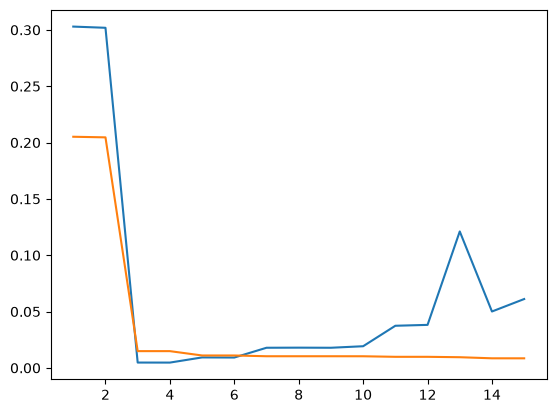

In [102]:
plt.plot(xaxes,vmses, label = "Validation MSE")
plt.plot(xaxes,tmses, label = "Train MSE")

In [103]:
def kfcv(x, y, k, d, hp):
    ind = np.arange(len(x))
    np.random.shuffle(ind)
    folds = np.array_split(ind, k)
    mses = []
    for i in range(k):
        val = folds[i]
        tran = np.hstack([folds[j] for j in range(k) if j != i])
        xt = x[tran]
        yt = y[tran]
        xc = x[val]
        yc = y[val]
        xtd = fu(xt, d)
        xcd = fu(xc, d)
        mod = fit(xtd, yt, 1e-8)
        pred = predict(mod, xcd)
        mses.append(np.mean((pred - yc) ** 2))
    return np.mean(mses)

In [104]:
cvm = [kfcv(s, y, k = 5, d = d, hp = 1e-8) for d in range(1, 16)]

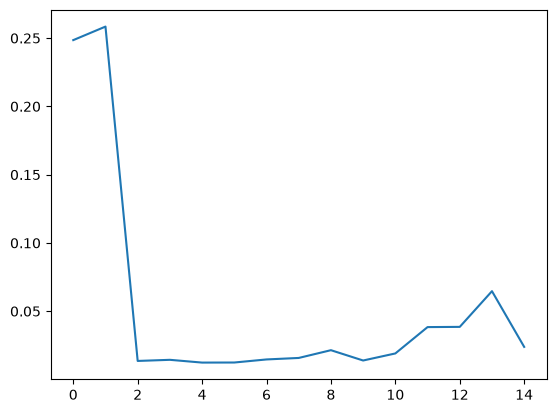

In [105]:
plt.plot(cvm)

In [107]:
xp = fu(s, 10)

In [118]:
lmbds = np.logspace(-4, 3, 100)
rf = []

In [119]:
for i in range(len(lmbds)):
    mod = fit(xp, y, lmbds[i])
    beta = mod["beta"]
    rf.append(beta)

In [120]:
np.shape(rf)

(100, 10)

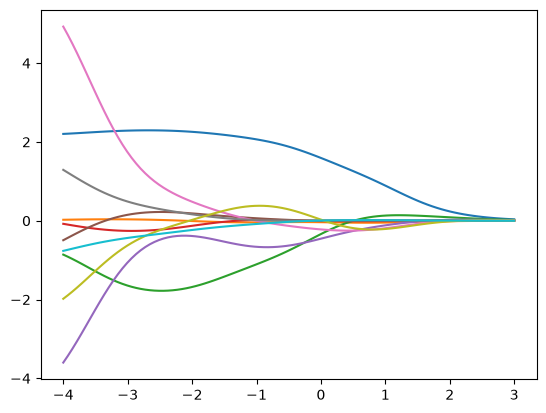

In [121]:
plt.plot(np.log10(lmbds), rf)

In [122]:
from sklearn.linear_model import Lasso

In [127]:
lf = []
for lam in lmbds:
    model = Lasso(alpha = lam, max_iter = 1000000)
    model.fit(xp, y)
    lf.append(model.coef_)

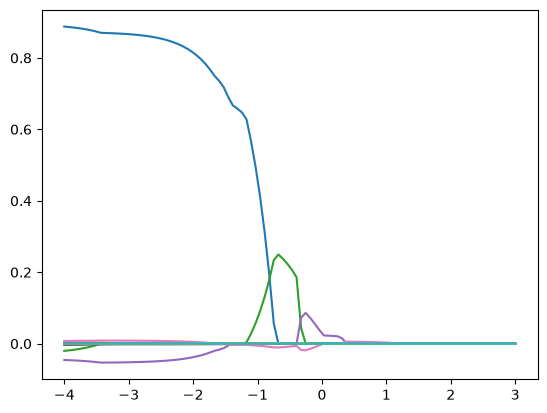

In [128]:
plt.plot(np.log10(lmbds), lf)